In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [10]:
titanic = sns.load_dataset("titanic")

features = ["pclass","sex","fare","embarked","age"]
target = ["survived"]

# handle missing data
imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

# encode
le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

X = titanic[features]
y = titanic["survived"]

# train test split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.3,random_state=42
)

In [ ]:
# Decision Tree
model = DecisionTreeClassifier()
model.fit(X_train,y_train)

y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

print("Training accuracy: ",accuracy_score(y_train,y_pred_train))
print("Testing accuracy: ",accuracy_score(y_test,y_pred_test))
# classic case of overfitting

Training accuracy:  0.9791332263242376
Testing accuracy:  0.7649253731343284


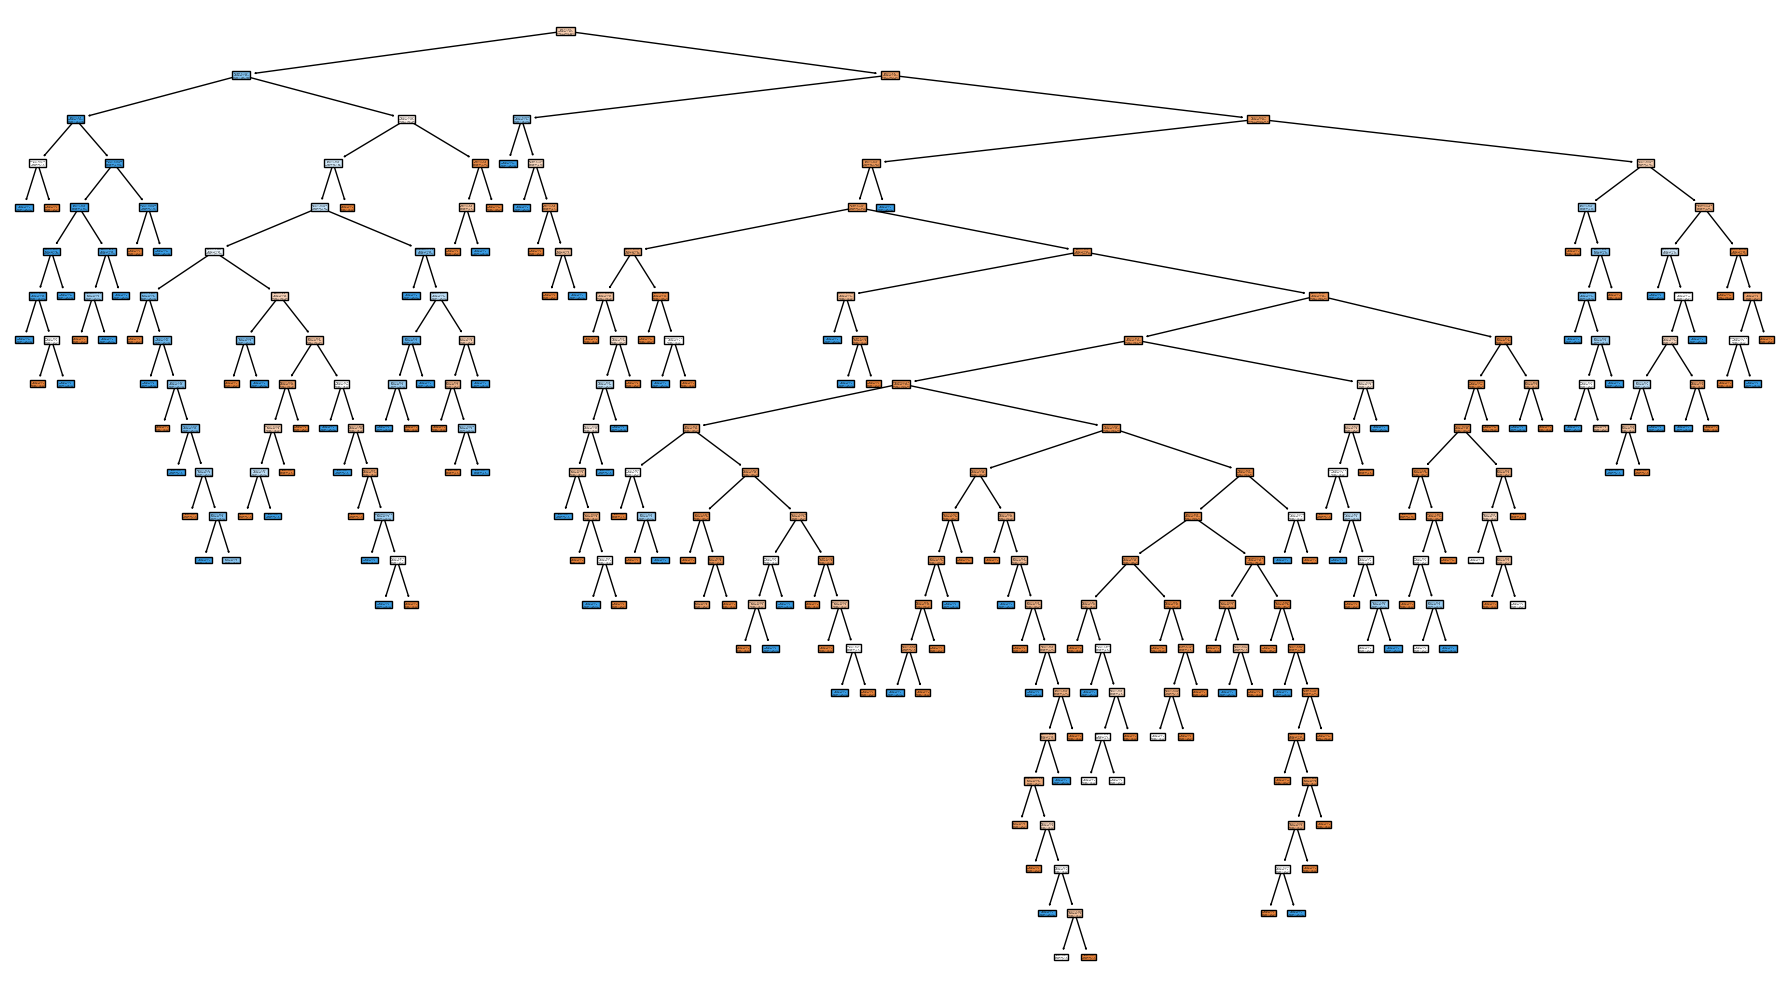

In [6]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))
plot_tree(
    model,feature_names=X.columns,
    class_names=["Died","Survived"],
    filled = True
)
plt.tight_layout()

In [11]:
# Random Forest 
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators = 201, # number of decision trees models
    oob_score = True # make it true if want to do oob validation
)

rf.fit(X_train,y_train)

y_pred_test = rf.predict(X_test)
y_pred_train = rf.predict(X_train)

print("OOB score: ",rf.oob_score_)

print("Training accuracy: ",accuracy_score(y_train,y_pred_train))
print("Testing accuracy: ",accuracy_score(y_test,y_pred_test))
# classic case of overfitting

OOB score:  0.8154093097913323
Training accuracy:  0.9791332263242376
Testing accuracy:  0.7798507462686567


In [13]:
# Bagging Classifier # randome forest is example of bagging enesemble which uses decision tree for ensenmbling and bagging (parallel) ensembling

from sklearn.ensemble import BaggingClassifier

base_model = DecisionTreeClassifier()

bagging = BaggingClassifier(
    base_model,
    n_estimators = 201
)

bagging.fit(X_train,y_train)

y_pred = bagging.predict(X_test)

print("accuracy: ",accuracy_score(y_test,y_pred))

accuracy:  0.7798507462686567


In [14]:
from sklearn.linear_model import LogisticRegression

base_model = LogisticRegression(max_iter=1000)

bagging = BaggingClassifier(
    base_model,
    n_estimators = 201
)

bagging.fit(X_train,y_train)

y_pred = bagging.predict(X_test)

print("accuracy: ",accuracy_score(y_test,y_pred))

accuracy:  0.7947761194029851
